In [41]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph , START , END
from IPython.display import Image
from typing import TypedDict
from dotenv import load_dotenv

load_dotenv()


True

In [32]:
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash"
)

In [21]:
#create a state
class LLMState(TypedDict):
    question: str
    answer: str

In [33]:
#define function to call the model
def LLM_qa(state: LLMState) -> LLMState:
    question = state["question"]
    prompt = f"Answer the following question: {question}"
    answer = model.invoke(prompt).content
    state["answer"] = answer
    return state

In [30]:
#create a graph
graph = StateGraph(LLMState)

#add node
graph.add_node("LLM_qa", LLM_qa)

#add edge
graph.add_edge(START, "LLM_qa")
graph.add_edge("LLM_qa", END)

#compile the graph
workflow = graph.compile()

In [37]:
#execute the graph
initial_state = LLMState(question="What is the capital of France?", answer="")
final_state = workflow.invoke(initial_state)
print(final_state)

{'question': 'What is the capital of France?', 'answer': 'The capital of France is **Paris**.'}


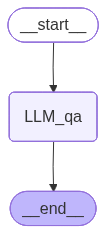

In [44]:
#generate visualization
Image(workflow.get_graph().draw_mermaid_png())